# Big Data Methods for Economists - Group 5

In [5]:
# Import used packages for Python Version 3.12.10 (see pyproject.toml)

import matplotlib.pyplot as plt
import numpy as np
import sklearn.datasets as datasets
import pandas as pd

print("Packages imported successfully!") 

Packages imported successfully!


In [6]:
bike_data = pd.read_csv('../ISLR-Datasets/Bikeshare.csv', header=0)
bike_data.head()

,Unnamed: 0,season,mnth,day,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,bikers
0,1,1,Jan,1,0,0,6,0,clear,0.24,0.2879,0.81,0.0,3,13,16
1,2,1,Jan,1,1,0,6,0,clear,0.22,0.2727,0.80,0.0,8,32,40
2,3,1,Jan,1,2,0,6,0,clear,0.22,0.2727,0.80,0.0,5,27,32
3,4,1,Jan,1,3,0,6,0,clear,0.24,0.2879,0.75,0.0,3,10,13
4,5,1,Jan,1,4,0,6,0,clear,0.24,0.2879,0.75,0.0,0,1,1


In [15]:
# Convert temperature from normalized scale to Celsius (assuming 0-1 scale maps to -8 to 39°C)
bike_data['temp_celsius'] = bike_data['temp'] * (39 - (-8)) + (-8)
# Convert "feels like" temperature from normalized scale to Celsius (assuming 0-1 scale maps to -16 to 50°C)
bike_data['atemp_celsius'] = bike_data['atemp'] * (50 - (-16)) + (-16)

# Aggregate data by day
bike_data['day_key'] = bike_data['day'].astype(str)
daily_data = bike_data.groupby('day_key').agg({'temp_celsius': 'mean', 'bikers': 'sum'}).reset_index()

# Extract variables for OLS
X_daily = daily_data['temp_celsius'].values
y_daily = daily_data['bikers'].values
X_daily_np = np.array(X_daily)
y_daily_np = np.array(y_daily)

def plot_bike_models(X_data=X_daily_np, y_data=y_daily_np, models=None, title="Bike Sharing Data", 
                     xlabel="Temperature", ylabel="Bike Rentals (Count)", filename=None):
    """
    Plots the base bike sharing scatter plot and overlays fitted models.
    
    Parameters:
    - X_data, y_data: Arrays for the background scatter plot.
    - models: List of dictionaries. Each dictionary represents a line to plot:
              {'x': X_plot_array, 'y': y_pred_array, 'label': 'Model Name', 'color': 'red'}
              (Optional keys: 'linestyle', 'linewidth')
    - title, xlabel, ylabel: Labels for the plot.
    """
    # 1. Setup Base Plot
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Scatter of raw data (Background)
    ax.scatter(X_data, y_data, alpha=0.3, color='blue', label='Daily Data')
    
    # 2. Loop through and plot each model
    if models:
        for model in models:
            # Get style properties with defaults
            linestyle = model.get('linestyle', '-')
            linewidth = model.get('linewidth', 2.5)
            
            ax.plot(model['x'], model['y'], 
                    color=model['color'], 
                    label=model['label'], 
                    linestyle=linestyle, 
                    linewidth=linewidth)

    # 3. Formatting
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_xlim(-5, 40)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.set_title(title, fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.legend()
    
    # 4. Save and Show
    if filename:
        plt.savefig(f"graphics/{filename}", format='pdf')
    plt.show()

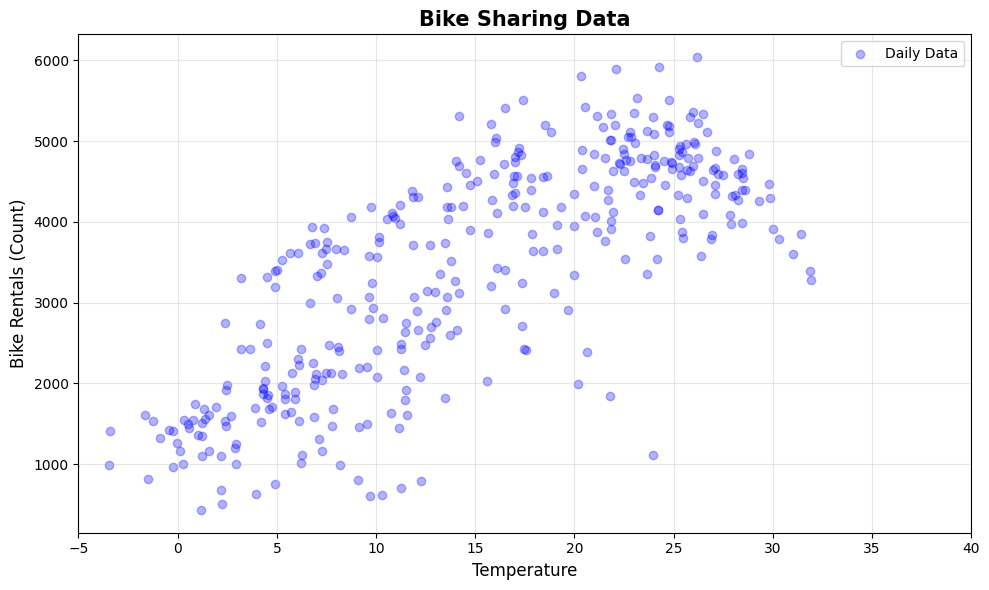

In [8]:
# Base plot with no models
plot_bike_models(filename="daily_temp_scatter.pdf")

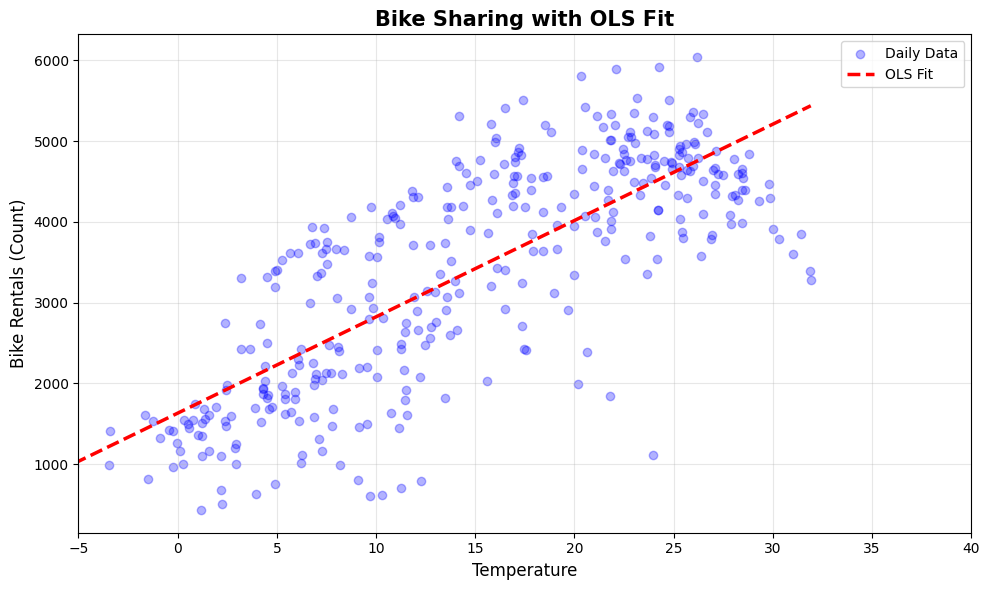

In [9]:
# Fit OLS (degree 1)
ols_coeffs_daily = np.polyfit(X_daily_np, y_daily_np, 1)
X_plot_daily = np.linspace(X_daily_np.min(), X_daily_np.max(), 100)
y_ols_daily = np.polyval(ols_coeffs_daily, X_plot_daily)

ols_model = {
    'x': X_plot_daily, 
    'y': y_ols_daily, 
    'label': 'OLS Fit', 
    'color': 'red', 
    'linestyle': '--'
}

plot_bike_models(models=[ols_model], title="Bike Sharing with OLS Fit", filename="bike_ols_fit.pdf")

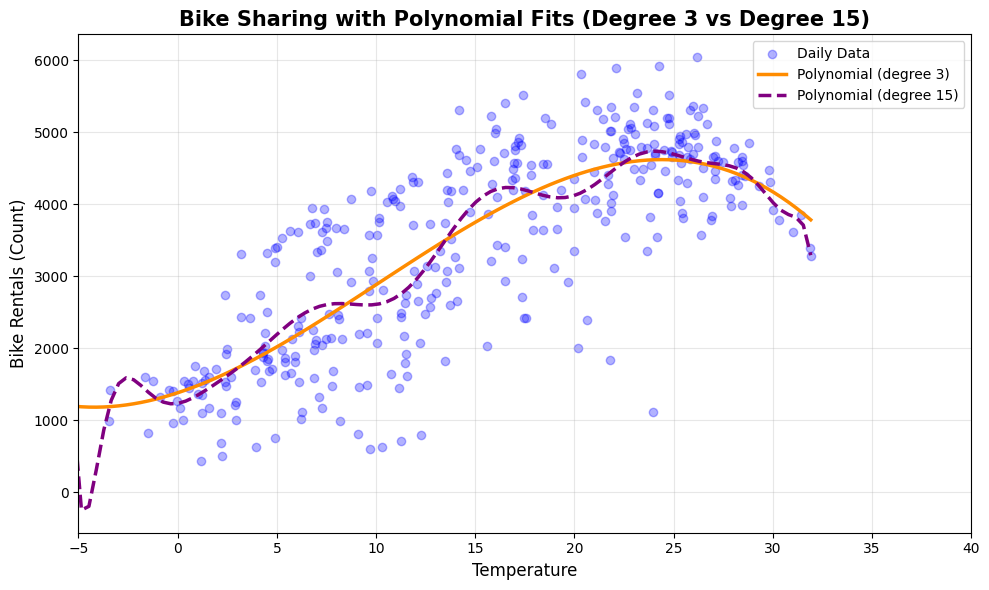

In [10]:
# Fit polynomial models
poly3_coeffs_daily = np.polyfit(X_daily_np, y_daily_np, 3)
poly15_coeffs_daily = np.polyfit(X_daily_np, y_daily_np, 15)

# Predict on existing plotting grid
y_poly3_daily = np.polyval(poly3_coeffs_daily, X_plot_daily)
y_poly15_daily = np.polyval(poly15_coeffs_daily, X_plot_daily)

# Build model specs for existing plotting function
poly3_model = {
    'x': X_plot_daily,
    'y': y_poly3_daily,
    'label': 'Polynomial (degree 3)',
    'color': 'darkorange'
}

poly15_model = {
    'x': X_plot_daily,
    'y': y_poly15_daily,
    'label': 'Polynomial (degree 15)',
    'color': 'purple',
    'linestyle': '--'
}

# Plot
plot_bike_models(
    models=[poly3_model, poly15_model],
    title='Bike Sharing with Polynomial Fits (Degree 3 vs Degree 15)',
    filename='bike_poly_comparison.pdf'
)

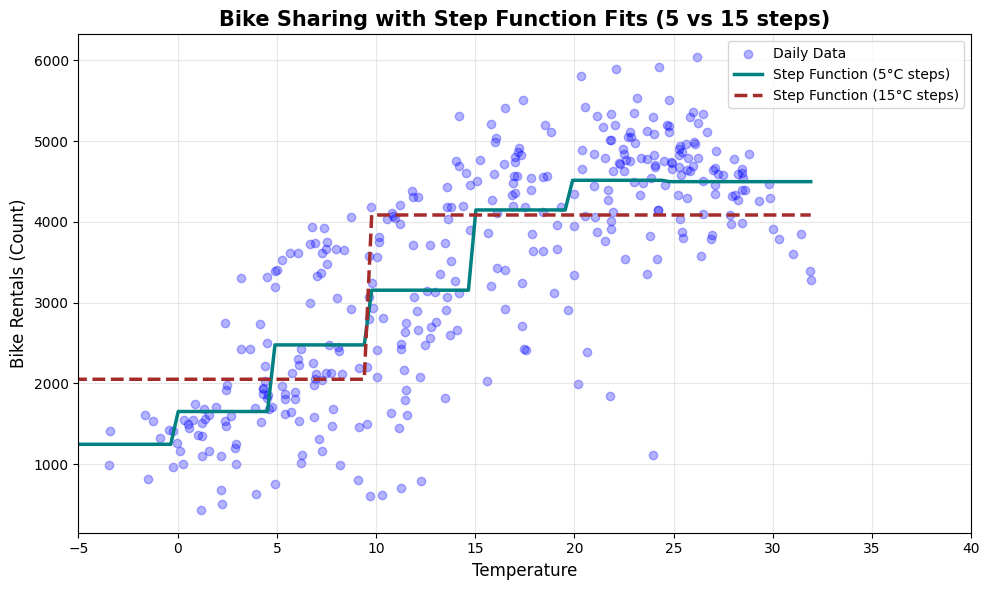

In [11]:
# Step function fits with 5 and 15 steps (using daily temperature data)

def step_function_predict(x_train, y_train, x_grid, stepsize):
    bins = np.arange(x_train.min(), x_train.max(), stepsize)
    train_bin_idx = np.digitize(x_train, bins[1:-1], right=False)
    
    # Mean response per bin
    bin_means = np.array([
        y_train[train_bin_idx == i].mean() if np.any(train_bin_idx == i) else y_train.mean()
        for i in range(len(bins) - 1)
    ])
    
    # Predict on grid
    grid_bin_idx = np.digitize(x_grid, bins[1:-1], right=False)
    return bin_means[grid_bin_idx]

y_step1_daily = step_function_predict(X_daily_np, y_daily_np, X_plot_daily, stepsize=1)
y_step5_daily = step_function_predict(X_daily_np, y_daily_np, X_plot_daily, stepsize=5)
y_step15_daily = step_function_predict(X_daily_np, y_daily_np, X_plot_daily, stepsize=15)

step1_model = {
    'x': X_plot_daily,
    'y': y_step1_daily,
    'label': 'Step Function (1°C steps)',
    'color': 'green'
}

step5_model = {
    'x': X_plot_daily,
    'y': y_step5_daily,
    'label': 'Step Function (5°C steps)',
    'color': 'teal'
}

step15_model = {
    'x': X_plot_daily,
    'y': y_step15_daily,
    'label': 'Step Function (15°C steps)',
    'color': 'brown',
    'linestyle': '--'
}

plot_bike_models(
    models=[step5_model, step15_model],
    title='Bike Sharing with Step Function Fits (5 vs 15 steps)',
    filename="bike_step_function_fits.pdf"
)

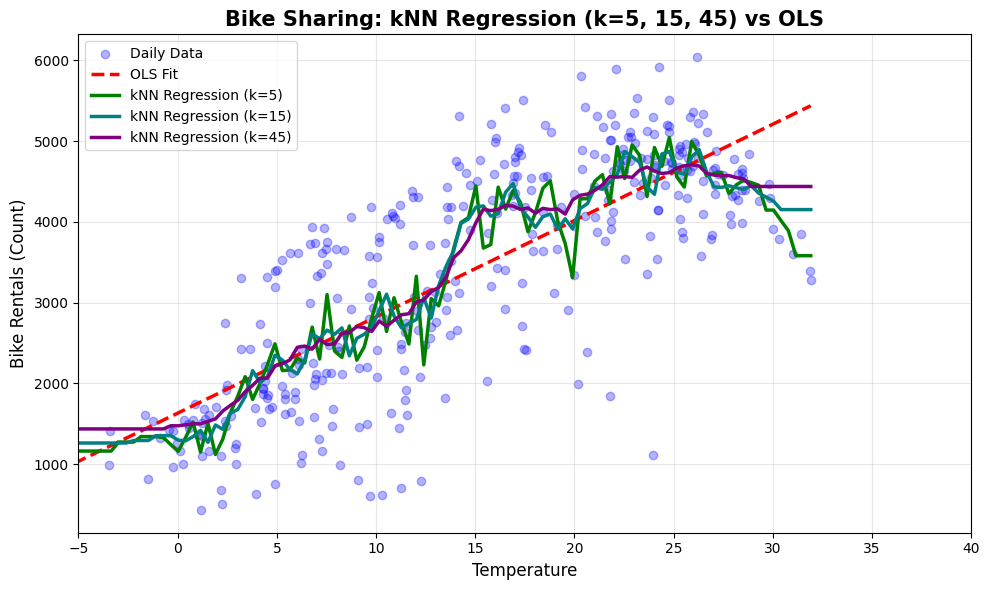

In [12]:
from sklearn.neighbors import KNeighborsRegressor

# kNN local regression on daily data
X_train_2d = X_daily_np.reshape(-1, 1)
X_plot_2d = X_plot_daily.reshape(-1, 1)

k_values = [5, 15, 45]
colors = ['green', 'teal', 'purple']
knn_models = []

for k_val, color in zip(k_values, colors):
    knn = KNeighborsRegressor(n_neighbors=k_val)
    knn.fit(X_train_2d, y_daily_np)
    y_knn = knn.predict(X_plot_2d)

    knn_models.append({
        'x': X_plot_daily,
        'y': y_knn,
        'label': f'kNN Regression (k={k_val})',
        'color': color
    })

plot_bike_models(
    models=[ols_model] + knn_models,
    title='Bike Sharing: kNN Regression (k=5, 15, 45) vs OLS',
    filename="bike_knn_comparison.pdf"
)

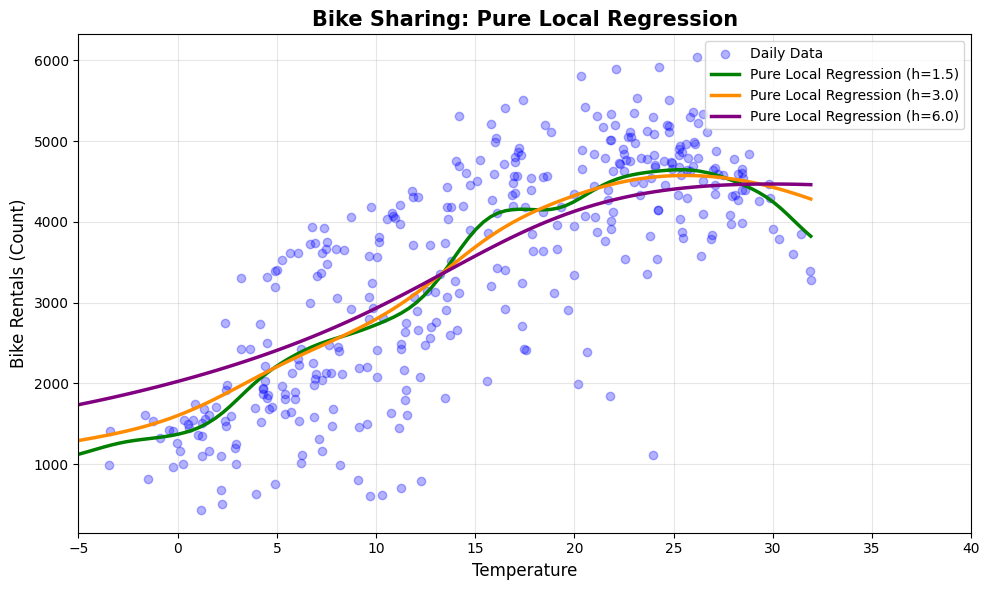

In [13]:
# Pure local regression (local-constant / kernel regression) on daily data

def local_constant_regression(x_train, y_train, x_grid, bandwidth=3.0):
    preds = np.zeros_like(x_grid, dtype=float)
    for i, x0 in enumerate(x_grid):
        w = np.exp(-0.5 * ((x_train - x0) / bandwidth) ** 2)  # Gaussian kernel
        w_sum = w.sum()
        preds[i] = (w @ y_train) / w_sum if w_sum > 0 else y_train.mean()
    return preds

# Fit pure local regression curves with different smoothness
bandwidths = [1.5, 3.0, 6.0]
colors = ['green', 'darkorange', 'purple']
local_models = []

for bw, c in zip(bandwidths, colors):
    y_local = local_constant_regression(X_daily_np, y_daily_np, X_plot_daily, bandwidth=bw)
    local_models.append({
        'x': X_plot_daily,
        'y': y_local,
        'label': f'Pure Local Regression (h={bw})',
        'color': c
    })

plot_bike_models(
    models=local_models,
    title='Bike Sharing: Pure Local Regression',
    filename="bike_local_regression.pdf"
)

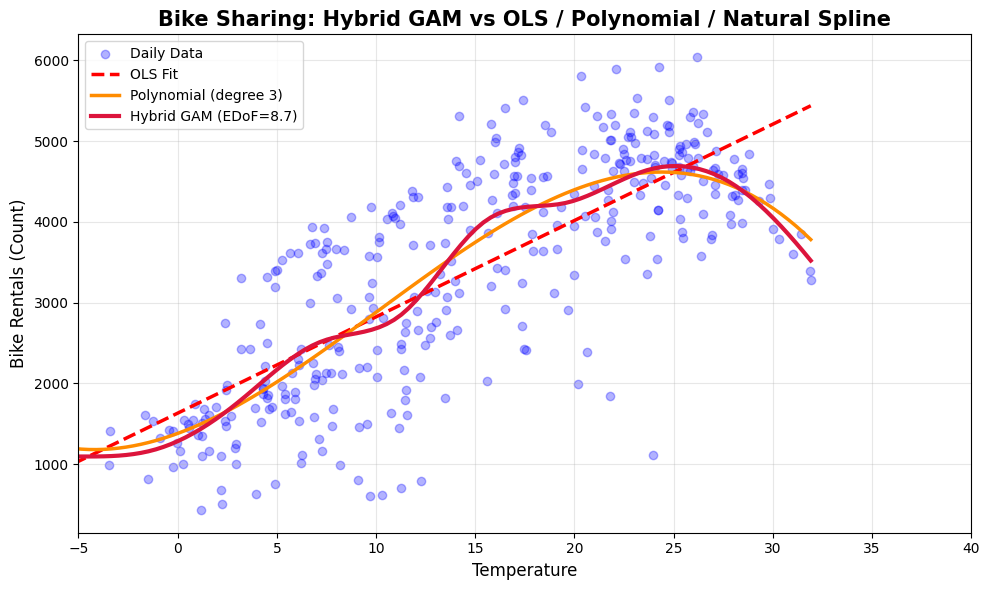

In [17]:
from pygam import LinearGAM, s

# Hybrid GAM: keeps smooth nonlinearity while controlling overfitting via penalty tuning
try:
    LinearGAM
except NameError:
    print("pygam not found. Please install pygam to run the GAM example.")

X_gam_train = X_daily_np.reshape(-1, 1)
X_gam_plot = X_plot_daily.reshape(-1, 1)

# Tune smoothness (lam) to balance flexibility (poly/step/local) and stability (OLS/spline)
lam_grid = np.logspace(-2, 3, 25)
gam_hybrid = LinearGAM(s(0, n_splines=12, spline_order=3)).gridsearch(
    X_gam_train, y_daily_np, lam=lam_grid, progress=False
)

y_gam_daily = gam_hybrid.predict(X_gam_plot)

gam_model = {
    'x': X_plot_daily,
    'y': y_gam_daily,
    'label': f'Hybrid GAM (EDoF={gam_hybrid.statistics_["edof"]:.1f})',
    'color': 'crimson',
    'linewidth': 3
}

plot_bike_models(
    models=[ols_model, poly3_model, gam_model],
    title='Bike Sharing: Hybrid GAM vs OLS / Polynomial / Natural Spline',
    filename="bike_gam_comparison.pdf"
)

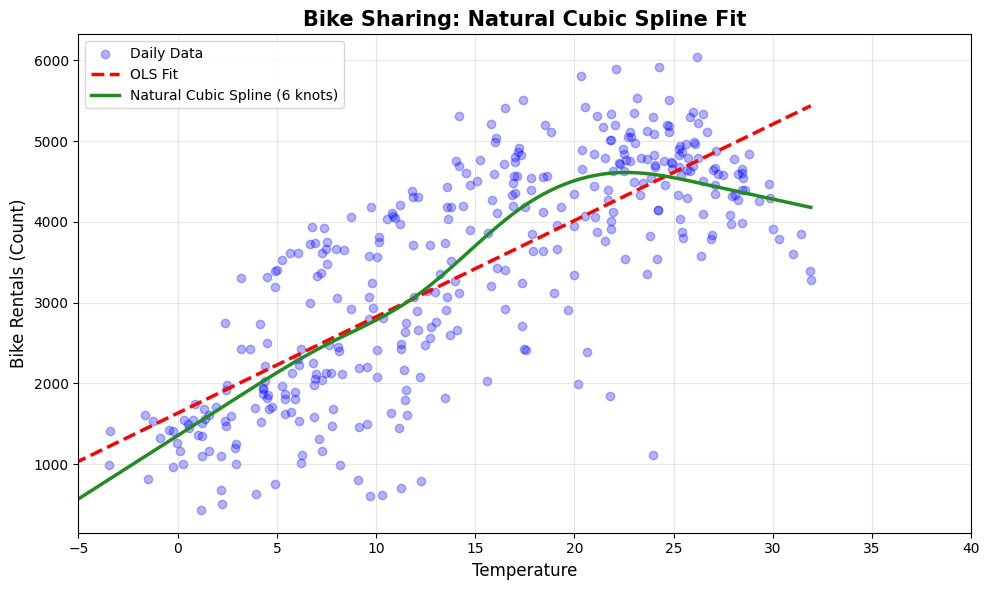

In [18]:
# Basis Function Regression (Natural Cubic Spline) on daily data

def natural_cubic_spline_basis(x, knots):
    """Create natural cubic spline basis matrix."""
    basis = [np.ones_like(x), x]
    for k in knots[:-1]:
        d = (np.maximum(x - k, 0)**3 - np.maximum(x - knots[-1], 0)**3) / (knots[-1] - k)
        d_prev = (np.maximum(x - knots[-2], 0)**3 - np.maximum(x - knots[-1], 0)**3) / (knots[-1] - knots[-2])
        basis.append(d - d_prev)
    return np.column_stack(basis)

# Place knots at quantiles of daily temperature
n_knots = 6
knots_daily = np.quantile(X_daily_np, np.linspace(0.1, 0.9, n_knots))

# Build basis matrices
B_train_daily = natural_cubic_spline_basis(X_daily_np, knots_daily)
B_plot_daily  = natural_cubic_spline_basis(X_plot_daily, knots_daily)

# Fit via OLS: beta = (B'B)^{-1} B'y
beta_spline_daily = np.linalg.lstsq(B_train_daily, y_daily_np, rcond=None)[0]
y_spline_daily = B_plot_daily @ beta_spline_daily

spline_model = {
    'x': X_plot_daily,
    'y': y_spline_daily,
    'label': f'Natural Cubic Spline ({n_knots} knots)',
    'color': 'forestgreen'
}

# Plot OLS + spline and visualize knot locations
y_knots_daily = natural_cubic_spline_basis(knots_daily, knots_daily) @ beta_spline_daily

plot_bike_models(
    models=[ols_model, spline_model],
    title='Bike Sharing: Natural Cubic Spline Fit',
    filename="bike_spline_fit.pdf"
)

Optimal Lambda found: 0.0000


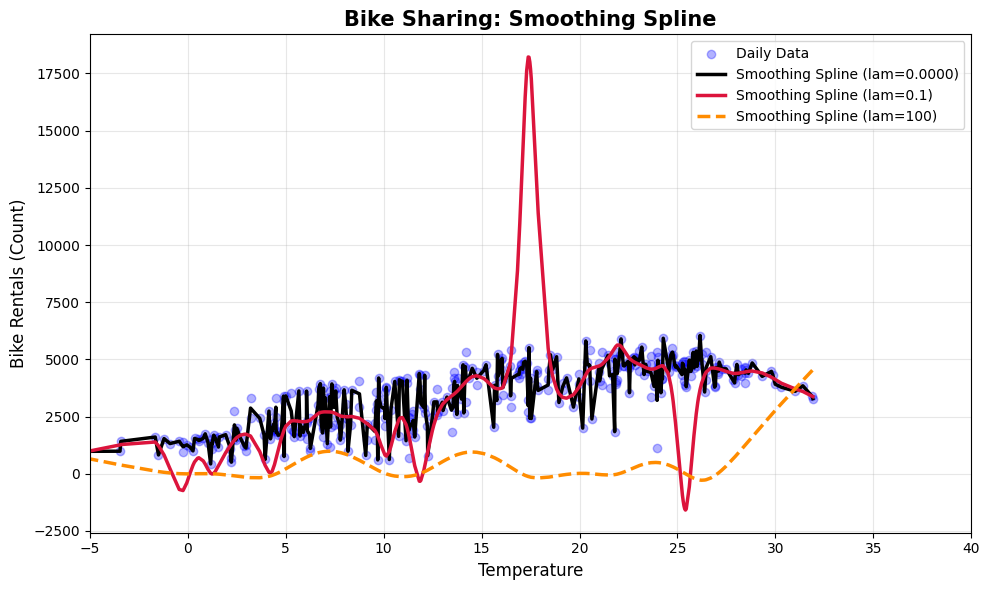

In [19]:
from scipy.interpolate import make_smoothing_spline

# --- Smoothing Spline (using make_smoothing_spline) ---
# Sort data for spline fitting
sort_idx = np.argsort(X_daily_np)
X_sorted = X_daily_np[sort_idx].astype(float)
y_sorted = y_daily_np[sort_idx].astype(float)

# make_smoothing_spline requires ascending x without duplicates.
# Aggregate duplicate x-values by averaging y within each unique x.
x_unique, inv, counts = np.unique(X_sorted, return_inverse=True, return_counts=True)
y_unique = np.bincount(inv, weights=y_sorted) / counts

# Create smoothing spline
spl = make_smoothing_spline(x_unique, y_unique, lam=0.1)
y_smoothing_spline = spl(x_unique)

best_lam = None
best_loocv_error = float('inf')

from scipy.interpolate import make_smoothing_spline

# 1. Aggregate duplicate x-values (Crucial for smoothing splines)
x_unique, inv, counts = np.unique(X_sorted, return_inverse=True, return_counts=True)
y_unique = np.bincount(inv, weights=y_sorted) / counts
w_unique = counts  # Weights

best_lam = None
best_loocv_error = float('inf')
loocv_errors = []
lambdas = np.logspace(-100, 5, 300) # 100 points grid search

# 2. Loop to find optimal Lambda
for lam in lambdas:
    # Fit spline with ALL data (no actual splitting needed for this formula)
    spl = make_smoothing_spline(x_unique, y_unique, w=w_unique, lam=lam)
    
    # Get fitted values y_hat
    y_hat = spl(x_unique)
    
    # --- CALCULATE DIAGONAL OF HAT MATRIX S ---
    # S_ii is roughly the 'leverage' of point i.
    # To get S_ii efficiently without full matrix inversion:
    # We can perturb y_i by 1 and see how much y_hat_i changes.
    # Since it's a linear smoother: S_ii = (spl(y + e_i) - spl(y))_i / 1
    # But fitting N times is slow. 
    # FAST APPROXIMATION for S_ii in smoothing splines:
    # S_ii approx = df / n  (where df is effective degrees of freedom)
    # BUT for the EXACT formula requested, we need exact S_ii.
    
    # For a truly correct implementation of the formula in Python without access to internals,
    # we simulate the probe. This is still slow (O(N^2)). 
    # A faster heuristic is often used in R/matlab internals.
    
    # Let's try the direct probe for datasets < 1000 points (our x_unique is small: ~365 days)
    n = len(x_unique)
    S_diag = np.zeros(n)
    
    # To get the i-th diagonal element of S, we predict for a unit vector e_i
    # Since y_hat = S @ y, if input is e_i, output is i-th column of S.
    # The i-th element of that output is S_ii.
    for i in range(n):
        e_i = np.zeros(n)
        e_i[i] = 1.0
        # We must use the SAME lambda and weights, but response e_i
        # Note: make_smoothing_spline is data-dependent on X, but linear in Y.
        # We can re-use the structure if we could, but here we just re-call it.
        # This is the bottleneck.
        spl_i = make_smoothing_spline(x_unique, e_i, w=w_unique, lam=lam)
        S_diag[i] = spl_i(x_unique)[i]
        
    # --- APPLY FAST LOOCV FORMULA ---
    # RSS_cv = sum( ( (y - y_hat) / (1 - S_ii) )^2 )
    
    residuals = y_unique - y_hat
    # Weighted version of the formula (since we have weights w_unique)
    # CV score = sum [ w_i * ((y_i - y_hat_i) / (1 - S_ii))^2 ]
    
    # Avoid division by zero if S_ii is very close to 1
    denom = 1 - S_diag
    denom[denom < 1e-6] = 1e-6
    
    loocv_error = np.sum(w_unique * (residuals / denom)**2)
    
    loocv_errors.append(loocv_error)
    
    if loocv_error < best_loocv_error:
        best_loocv_error = loocv_error
        best_lam = lam

print(f"Optimal Lambda found: {best_lam:.4f}")

# 3. Fit optimal model
spl_optimal = make_smoothing_spline(x_unique, y_unique, w=w_unique, lam=best_lam)
y_smoothing_spline_optimal = spl_optimal(x_unique) # Evaluate on unique sorted grid for smooth line in plot

spl_1000 = make_smoothing_spline(x_unique, y_unique, lam=100)
y_smoothing_spline_1000 = spl_1000(x_unique)

# Plot comparison of smoothing spline with other models

smoothing_spline_model_optimal = {
    'x': x_unique,
    'y': y_smoothing_spline_optimal,
    'label': f'Smoothing Spline (lam={best_lam:.4f})',
    'color': 'black',
    'linewidth': 2.5
}

smoothing_spline_model = {
    'x': x_unique,
    'y': y_smoothing_spline,
    'label': 'Smoothing Spline (lam=0.1)',
    'color': 'crimson',
    'linewidth': 2.5
}

smoothing_spline_model_1000 = {
    'x': x_unique,
    'y': y_smoothing_spline_1000,
    'label': 'Smoothing Spline (lam=100)',
    'color': 'darkorange',
    'linestyle': '--', 
    'linewidth': 2.5
}


plot_bike_models(
    models=[smoothing_spline_model_optimal, smoothing_spline_model, smoothing_spline_model_1000],
    title='Bike Sharing: Smoothing Spline',
    filename="bike_smoothing_spline_comparison.pdf"
)

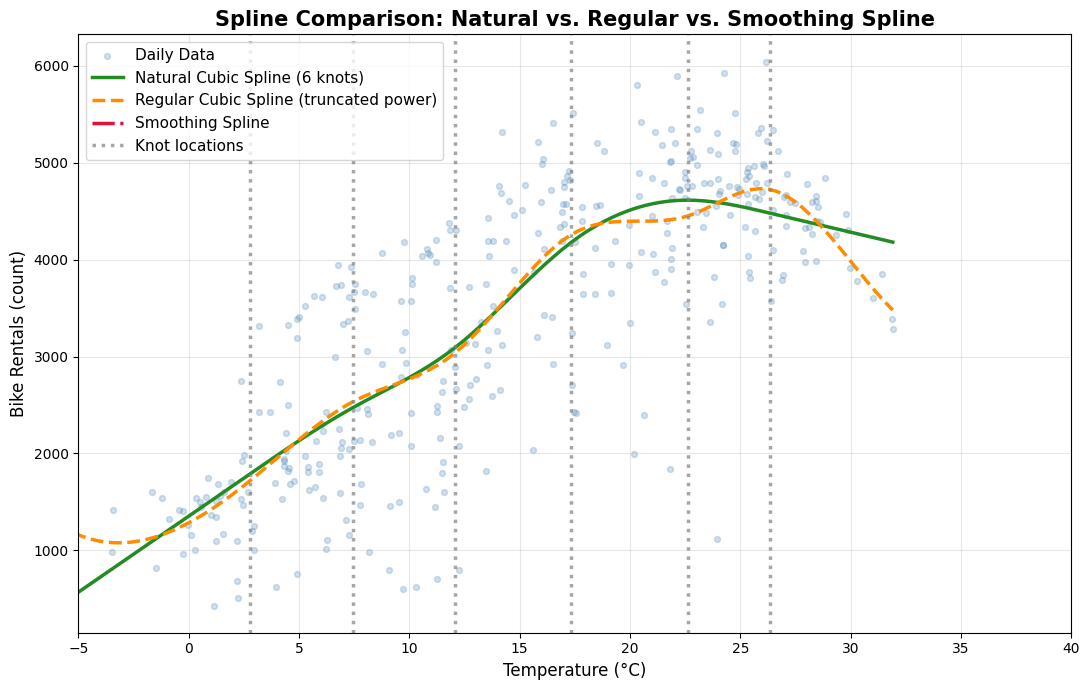

In [ ]:
from scipy.interpolate import UnivariateSpline

# --- 1. Natural Cubic Spline (reuse existing function & knots) ---
# Already defined: natural_cubic_spline_basis, knots_daily, beta_spline_daily
B_plot_nat = natural_cubic_spline_basis(X_plot_daily, knots_daily)
y_natural = B_plot_nat @ beta_spline_daily

# --- 2. Regular (Truncated Power) Cubic Spline ---
def truncated_power_spline_basis(x, knots):
    """Truncated power basis (unrestricted cubic spline)."""
    basis = [np.ones_like(x), x, x**2, x**3]
    for k in knots:
        basis.append(np.maximum(x - k, 0)**3)
    return np.column_stack(basis)

B_train_tp = truncated_power_spline_basis(X_daily_np, knots_daily)
B_plot_tp  = truncated_power_spline_basis(X_plot_daily, knots_daily)
beta_tp    = np.linalg.lstsq(B_train_tp, y_daily_np, rcond=None)[0]
y_truncated = B_plot_tp @ beta_tp

# --- 3. Smoothing Spline (via scipy UnivariateSpline with smoothing factor) ---
sort_idx   = np.argsort(X_daily_np)
X_sorted   = X_daily_np[sort_idx]
y_sorted   = y_daily_np[sort_idx].astype(float)
smooth_spline = UnivariateSpline(X_sorted, y_sorted, k=3, s=len(X_sorted) * 3000)
y_smoothing   = smooth_spline(X_plot_daily)

# --- Plot ---
fig, ax = plt.subplots(figsize=(11, 7))

# Scatter of raw data
ax.scatter(X_daily_np, y_daily_np, alpha=0.25, color='steelblue', s=18, label='Daily Data', zorder=1)

# Model lines
ax.plot(X_plot_daily, y_natural,   color='forestgreen',  linewidth=2.5, label='Natural Cubic Spline (6 knots)')
ax.plot(X_plot_daily, y_truncated, color='darkorange',    linewidth=2.5, label='Regular Cubic Spline (truncated power)', linestyle='--')
ax.plot(X_plot_daily, y_smoothing, color='crimson',       linewidth=2.5, label='Smoothing Spline', linestyle='-.')

# Knot locations (thicker than before)
for i, k in enumerate(knots_daily):
    ax.axvline(k, color='gray', linestyle=':', alpha=0.7, linewidth=2.5,
               label='Knot locations' if i == 0 else None)

ax.set_title('Spline Comparison: Natural vs. Regular vs. Smoothing Spline', fontsize=15, fontweight='bold')
ax.set_xlabel('Temperature (°C)', fontsize=12)
ax.set_ylabel('Bike Rentals (count)', fontsize=12)
ax.set_xlim(-5, 40)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
# Load the bike sharing dataset
bike_data = datasets.fetch_openml(name='Bike_Sharing_Demand', version=2, as_frame=True)
df = bike_data.frame

# Filter for 2012 data
df['year'] = df['year'].astype(int)
df_2012 = df[df['year'] == 1].copy()  # year=1 corresponds to 2012 in this dataset

# Extract temperature and count
X = df_2012['temp'].values.astype(float)
y = df_2012['count'].values.astype(float)

# Aggregate data daily
df_2012['datetime'] = pd.to_datetime(df_2012.index)
df_daily = df_2012.groupby(df_2012.index.astype(str).str[:10]).agg({'temp': 'mean', 'count': 'sum'}).reset_index()
X = df_daily['temp'].values.astype(float)
y = df_daily['count'].values.astype(float)

# Sort for plotting
sort_idx = np.argsort(X)
X_sorted = X[sort_idx]
y_sorted = y[sort_idx]

X_plot = np.linspace(X.min(), X.max(), 300)

# --- OLS (degree 1) ---
ols_coeffs = np.polyfit(X, y, 1)
ols_pred = np.polyval(ols_coeffs, X_plot)

# --- Polynomial Regression (degree 5) ---
poly_coeffs = np.polyfit(X, y, 5)
poly_pred = np.polyval(poly_coeffs, X_plot)

# --- Plot ---
fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(X, y, alpha=0.15, color='gray', s=10, label='Data')
ax.plot(X_plot, ols_pred, color='royalblue', linewidth=2.5, label='OLS (degree 1)')
ax.plot(X_plot, poly_pred, color='tomato', linewidth=2.5, label='Polynomial (degree 5)')
ax.set_xlabel('Temperature (normalized)', fontsize=12)
ax.set_ylabel('Bike Rentals (count)', fontsize=12)

ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.title('Bike Sharing: Temperature vs Rentals (2012)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

NameError: name 'pd' is not defined

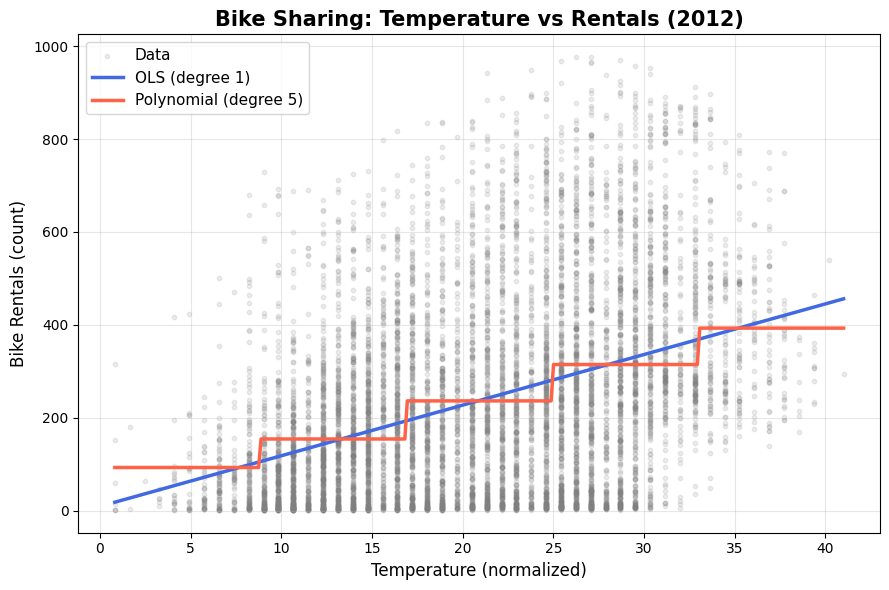

In [ ]:
# Load the bike sharing dataset
bike_data = datasets.fetch_openml(name='Bike_Sharing_Demand', version=2, as_frame=True)
df = bike_data.frame

# Filter for 2012 data
df['year'] = df['year'].astype(int)
df_2012 = df[df['year'] == 1].copy()  # year=1 corresponds to 2012 in this dataset

# Extract temperature and count
X = df_2012['temp'].values.astype(float)
y = df_2012['count'].values.astype(float)

# Sort for plotting
sort_idx = np.argsort(X)
X_sorted = X[sort_idx]
y_sorted = y[sort_idx]

X_plot = np.linspace(X.min(), X.max(), 300)

# --- OLS (degree 1) ---
ols_coeffs = np.polyfit(X, y, 1)
ols_pred = np.polyval(ols_coeffs, X_plot)

# --- Polynomial Regression (degree 5) ---
# --- Step Function Regression (5 steps) ---
n_steps = 5
bins = np.linspace(X.min(), X.max(), n_steps + 1)
bin_indices = np.digitize(X, bins[1:-1])  # assign each X to a bin

step_pred = np.zeros(len(X_plot))
for i in range(n_steps):
    mask = bin_indices == i
    if mask.sum() > 0:
        step_mean = y[mask].mean()
    plot_mask = (X_plot >= bins[i]) & (X_plot < bins[i + 1])
    step_pred[plot_mask] = step_mean
step_pred[X_plot >= bins[-1]] = step_mean  # fill last bin edge
poly_pred = step_pred

# --- Plot ---
fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(X, y, alpha=0.15, color='gray', s=10, label='Data')
ax.plot(X_plot, ols_pred, color='royalblue', linewidth=2.5, label='OLS (degree 1)')
ax.plot(X_plot, poly_pred, color='tomato', linewidth=2.5, label='Polynomial (degree 5)')
ax.set_xlabel('Temperature (normalized)', fontsize=12)
ax.set_ylabel('Bike Rentals (count)', fontsize=12)

ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.title('Bike Sharing: Temperature vs Rentals (2012)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

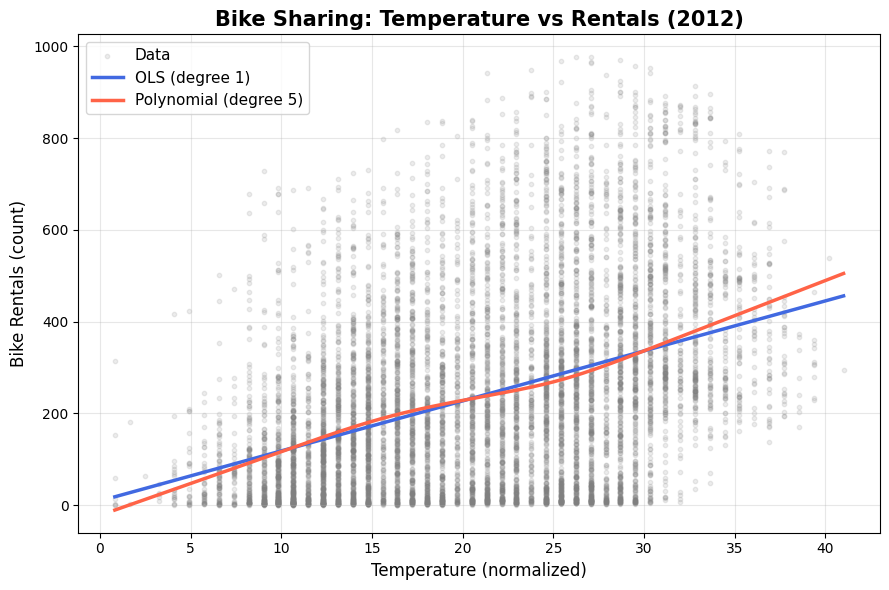

In [ ]:
from numpy.polynomial import polynomial as P

# Load the bike sharing dataset
bike_data = datasets.fetch_openml(name='Bike_Sharing_Demand', version=2, as_frame=True)
df = bike_data.frame

# Filter for 2012 data
df['year'] = df['year'].astype(int)
df_2012 = df[df['year'] == 1].copy()  # year=1 corresponds to 2012 in this dataset

# Extract temperature and count
X = df_2012['temp'].values.astype(float)
y = df_2012['count'].values.astype(float)

# Sort for plotting
sort_idx = np.argsort(X)
X_sorted = X[sort_idx]
y_sorted = y[sort_idx]

X_plot = np.linspace(X.min(), X.max(), 300)

# --- OLS (degree 1) ---
ols_coeffs = np.polyfit(X, y, 1)
ols_pred = np.polyval(ols_coeffs, X_plot)

# --- Basis Function Regression (Natural Cubic Spline with 5 knots) ---

n_knots = 5
knots = np.quantile(X, np.linspace(0.1, 0.9, n_knots))

def natural_cubic_spline_basis(x, knots):
    """Create natural cubic spline basis matrix."""
    n = len(knots)
    basis = [np.ones_like(x), x]
    for k in knots[:-1]:
        d = (np.maximum(x - k, 0)**3 - np.maximum(x - knots[-1], 0)**3) / (knots[-1] - k)
        d_prev = (np.maximum(x - knots[-2], 0)**3 - np.maximum(x - knots[-1], 0)**3) / (knots[-1] - knots[-2])
        basis.append(d - d_prev)
    return np.column_stack(basis)

B_train = natural_cubic_spline_basis(X, knots)
B_plot = natural_cubic_spline_basis(X_plot, knots)

# Fit via OLS: beta = (B'B)^{-1} B'y
beta = np.linalg.lstsq(B_train, y, rcond=None)[0]
poly_pred = B_plot @ beta

# --- Plot ---
fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(X, y, alpha=0.15, color='gray', s=10, label='Data')
ax.plot(X_plot, ols_pred, color='royalblue', linewidth=2.5, label='OLS (degree 1)')
ax.plot(X_plot, poly_pred, color='tomato', linewidth=2.5, label='Polynomial (degree 5)')
ax.set_xlabel('Temperature (normalized)', fontsize=12)
ax.set_ylabel('Bike Rentals (count)', fontsize=12)

ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.title('Bike Sharing: Temperature vs Rentals (2012)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

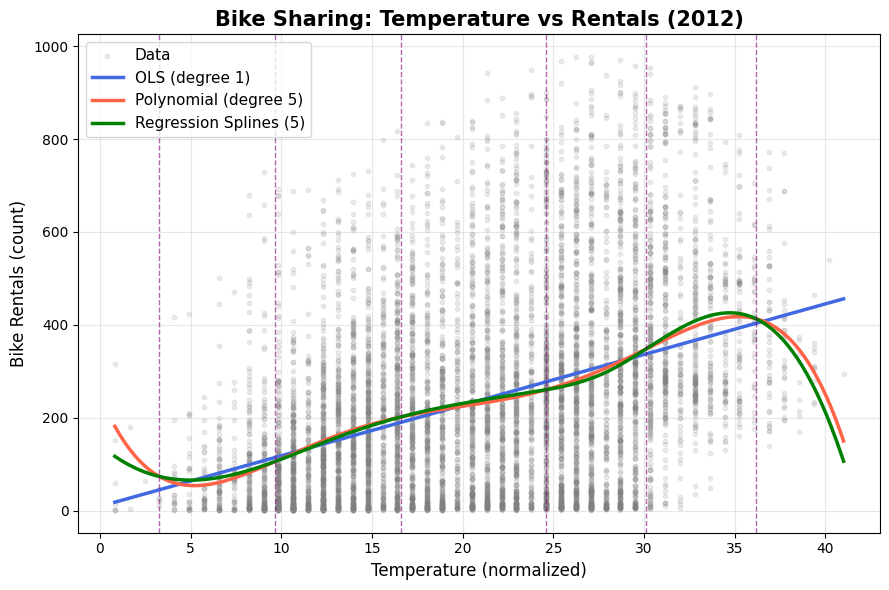

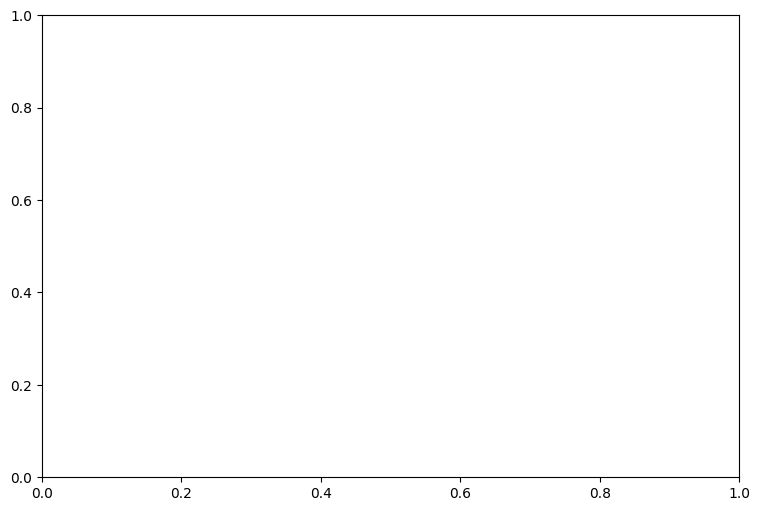

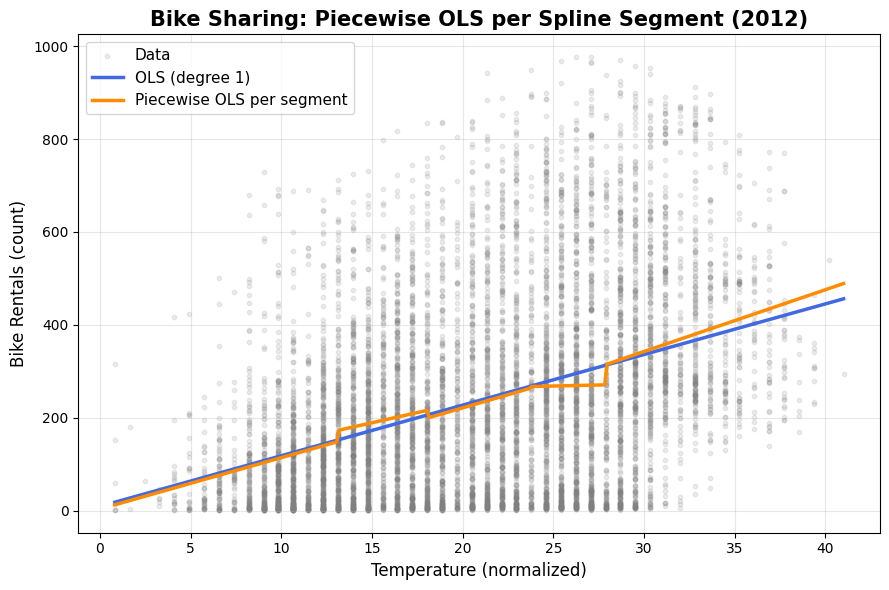

In [ ]:
# Extract temperature and count (reuse from existing variables)
X_plot = np.linspace(X.min(), X.max(), 300)

# --- OLS (degree 1) ---
ols_coeffs = np.polyfit(X, y, 1)
ols_pred = np.polyval(ols_coeffs, X_plot)

# --- Polynomial Regression (degree 5) ---
poly_coeffs = np.polyfit(X, y, 5)
poly_pred = np.polyval(poly_coeffs, X_plot)

# --- Regression Splines (5 basis splines with 4 interior knots) ---
n_knots = 4
knots_rs = np.quantile(X, np.linspace(0.2, 0.8, n_knots))

def regression_spline_basis(x, knots):
    """Create regression spline (truncated power) basis matrix."""
    basis = [np.ones_like(x), x, x**2, x**3]
    for k in knots:
        basis.append(np.maximum(x - k, 0)**3)
    return np.column_stack(basis)

# --- Compute intersection points between spline and polynomial predictions ---
diff = spline_pred - poly_pred
sign_changes = np.where(np.diff(np.sign(diff)))[0]
intersect_x = [X_plot[i] + (X_plot[i+1] - X_plot[i]) * (-diff[i] / (diff[i+1] - diff[i])) for i in sign_changes]

B_train_rs = regression_spline_basis(X, knots_rs)
B_plot_rs = regression_spline_basis(X_plot, knots_rs)

beta_rs = np.linalg.lstsq(B_train_rs, y, rcond=None)[0]
spline_pred = B_plot_rs @ beta_rs

# --- Plot ---
fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(X, y, alpha=0.15, color='gray', s=10, label='Data')
ax.plot(X_plot, ols_pred, color='royalblue', linewidth=2.5, label='OLS (degree 1)')
ax.plot(X_plot, poly_pred, color='tomato', linewidth=2.5, label='Polynomial (degree 5)')
ax.plot(X_plot, spline_pred, color='green', linewidth=2.5, label='Regression Splines (5)')
ax.set_xlabel('Temperature (normalized)', fontsize=12)
ax.set_ylabel('Bike Rentals (count)', fontsize=12)

for ix in intersect_x:
    ax.axvline(x=ix, color='purple', linewidth=1, linestyle='--', alpha=0.6)

ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.title('Bike Sharing: Temperature vs Rentals (2012)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
# --- Piecewise OLS per spline segment (using knots_rs as breakpoints) ---
breakpoints = np.concatenate([[X.min()], knots_rs, [X.max()]])
spline_pred_piecewise = np.zeros(len(X_plot))

for seg in range(len(breakpoints) - 1):
    seg_mask_train = (X >= breakpoints[seg]) & (X <= breakpoints[seg + 1])
    seg_mask_plot = (X_plot >= breakpoints[seg]) & (X_plot <= breakpoints[seg + 1])
    if seg_mask_train.sum() > 1:
        X_seg = X[seg_mask_train]
        y_seg = y[seg_mask_train]
        A = np.column_stack([np.ones_like(X_seg), X_seg])
        beta_seg = np.linalg.lstsq(A, y_seg, rcond=None)[0]
        X_plot_seg = X_plot[seg_mask_plot]
        spline_pred_piecewise[seg_mask_plot] = beta_seg[0] + beta_seg[1] * X_plot_seg

ax2, fig2 = plt.subplots if False else (None, plt.subplots(figsize=(9, 6)))
fig2, ax2 = plt.subplots(figsize=(9, 6))
ax2.scatter(X, y, alpha=0.15, color='gray', s=10, label='Data')
ax2.plot(X_plot, ols_pred, color='royalblue', linewidth=2.5, label='OLS (degree 1)')
ax2.plot(X_plot, spline_pred_piecewise, color='darkorange', linewidth=2.5, label='Piecewise OLS per segment')
ax2.set_xlabel('Temperature (normalized)', fontsize=12)
ax2.set_ylabel('Bike Rentals (count)', fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
plt.title('Bike Sharing: Piecewise OLS per Spline Segment (2012)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

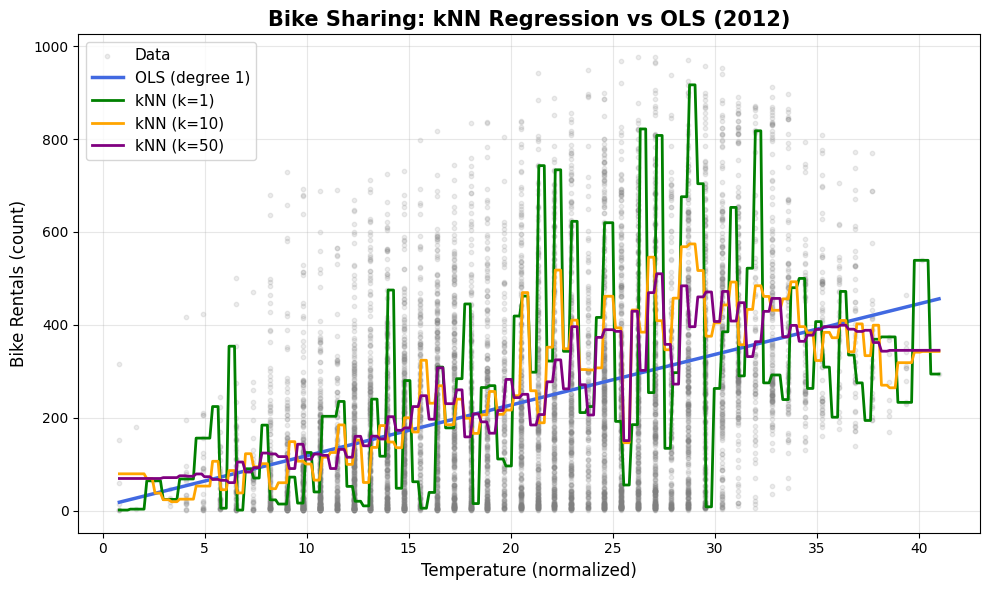

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

# Prepare data
X_2d = X.reshape(-1, 1)
X_plot_2d = X_plot.reshape(-1, 1)

# Fit kNN for different k values
k_values = [1, 10, 50]
colors = ['green', 'orange', 'purple']
knn_preds = {}

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_2d, y)
    knn_preds[k] = knn.predict(X_plot_2d)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(X, y, alpha=0.15, color='gray', s=10, label='Data')
ax.plot(X_plot, ols_pred, color='royalblue', linewidth=2.5, label='OLS (degree 1)')

for k, color in zip(k_values, colors):
    ax.plot(X_plot, knn_preds[k], linewidth=2, color=color, label=f'kNN (k={k})')

ax.set_xlabel('Temperature (normalized)', fontsize=12)
ax.set_ylabel('Bike Rentals (count)', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.title('Bike Sharing: kNN Regression vs OLS (2012)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

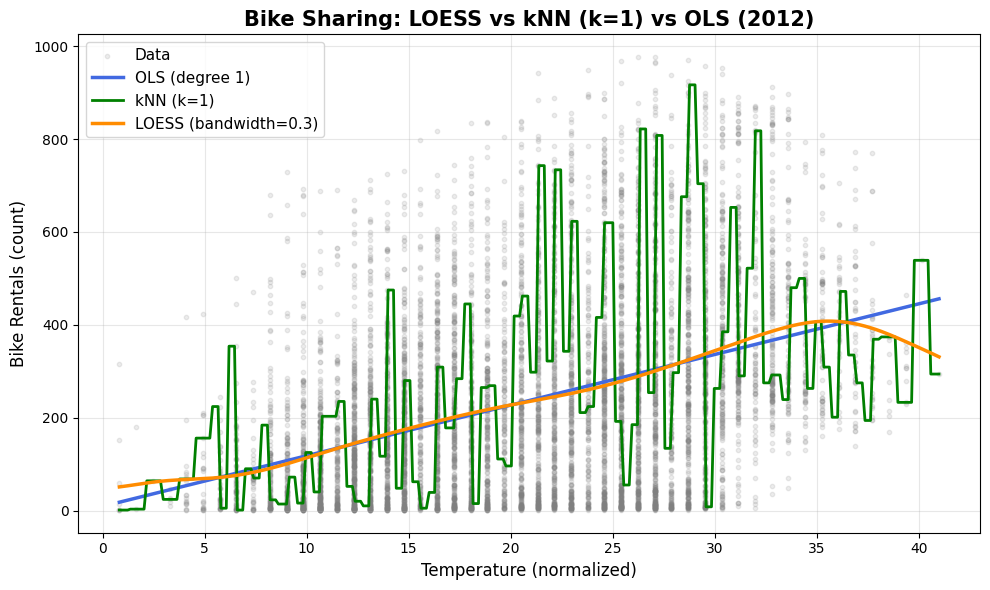

In [ ]:
from sklearn.linear_model import LinearRegression

# --- LOESS implementation ---
def loess(x_train, y_train, x_pred, bandwidth=0.3):
    """Local regression (LOESS) using tricubic kernel weights."""
    n = len(x_train)
    x_range = x_train.max() - x_train.min()
    
    predictions = np.zeros(len(x_pred))
    for i, x0 in enumerate(x_pred):
        # Compute distances and weights (tricubic kernel)
        distances = np.abs(x_train - x0)
        h = bandwidth * x_range
        u = distances / h
        weights = np.where(u < 1, (1 - u**3)**3, 0)
        
        # Weighted OLS: fit local linear model
        if weights.sum() > 0:
            W = np.diag(weights)
            A = np.column_stack([np.ones(n), x_train])
            beta = np.linalg.lstsq(W @ A, W @ y_train, rcond=None)[0]
            predictions[i] = beta[0] + beta[1] * x0
    return predictions

# Compute LOESS predictions
loess_pred = loess(X, y, X_plot, bandwidth=0.3)

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(X, y, alpha=0.15, color='gray', s=10, label='Data')
ax.plot(X_plot, ols_pred, color='royalblue', linewidth=2.5, label='OLS (degree 1)')
ax.plot(X_plot, knn_preds[1], color='green', linewidth=2, label='kNN (k=1)')
ax.plot(X_plot, loess_pred, color='darkorange', linewidth=2.5, label='LOESS (bandwidth=0.3)')

ax.set_xlabel('Temperature (normalized)', fontsize=12)
ax.set_ylabel('Bike Rentals (count)', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.title('Bike Sharing: LOESS vs kNN (k=1) vs OLS (2012)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

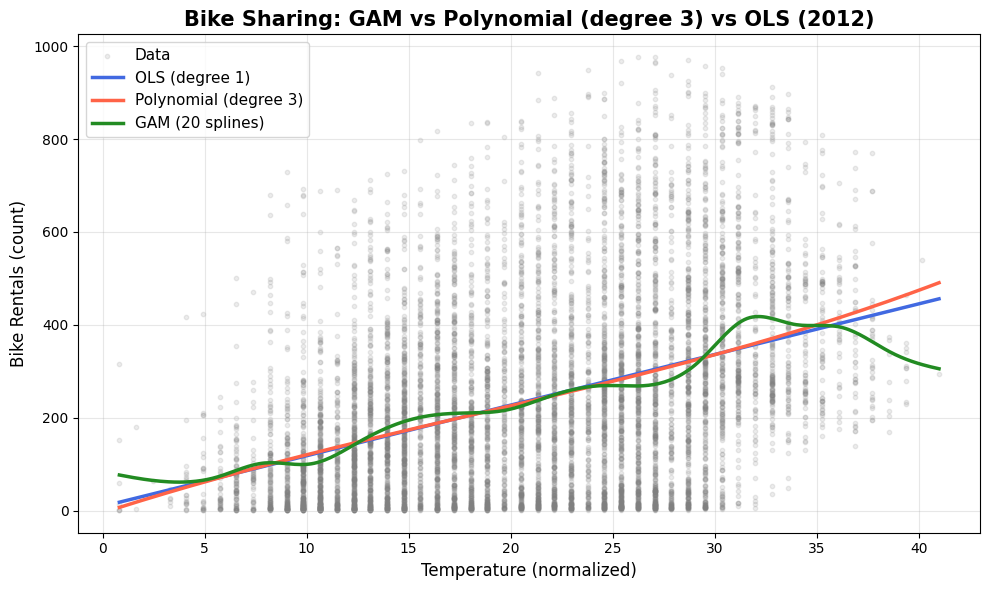

In [ ]:
from pygam import LinearGAM, s

# --- Polynomial Regression (degree 3) ---
poly3_coeffs = np.polyfit(X, y, 3)
poly3_pred = np.polyval(poly3_coeffs, X_plot)

# --- GAM with spline term ---
gam = LinearGAM(s(0, n_splines=20, spline_order=3)).fit(X.reshape(-1, 1), y)
gam_pred = gam.predict(X_plot.reshape(-1, 1))

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(X, y, alpha=0.15, color='gray', s=10, label='Data')
ax.plot(X_plot, ols_pred, color='royalblue', linewidth=2.5, label='OLS (degree 1)')
ax.plot(X_plot, poly3_pred, color='tomato', linewidth=2.5, label='Polynomial (degree 3)')
ax.plot(X_plot, gam_pred, color='forestgreen', linewidth=2.5, label='GAM (20 splines)')

ax.set_xlabel('Temperature (normalized)', fontsize=12)
ax.set_ylabel('Bike Rentals (count)', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.title('Bike Sharing: GAM vs Polynomial (degree 3) vs OLS (2012)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()